Environment Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Detected Google Colab. Bypassing dependency resolver...")

    !pip install timm
    !pip install git+https://github.com/IBM/terratorch.git
else:
    print("Running locally. Assuming repository is already downloaded.")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(os.path.abspath(os.getcwd()))

Detected Google Colab. Bypassing dependency resolver...
  Cloning https://github.com/IBM/terratorch.git to /tmp/pip-req-build-q2_twcb_
  Running command git clone --filter=blob:none --quiet https://github.com/IBM/terratorch.git /tmp/pip-req-build-q2_twcb_
  Resolved https://github.com/IBM/terratorch.git to commit d1267fbd278cd23bc05a1c22cc077e18481dd7c0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

Note: Please restart the Colab session before proceeding to avoid dependency conflicts.

In [1]:
print("\nCloning the official repository...")
!git clone https://github.com/karol140903/terramind-adversarial-robustness.git

%cd terramind-adversarial-robustness


Cloning the official repository...
fatal: destination path 'terramind-adversarial-robustness' already exists and is not an empty directory.
/content/terramind-adversarial-robustness


Global Setup, Imports & Targeted Attack Logic

In [2]:
import torch
import pandas as pd
from tqdm.notebook import tqdm
from terratorch import BACKBONE_REGISTRY

# Import core project modules
from src.attacks import pgd_spectral_group
from src.metrics import compute_metrics
from src.utils import set_seed
from src.dataset import BANDS_ORDER

# Lock the global environment to ensure deterministic execution
set_seed(42)
print("Global environment locked with fixed seed (42).")

# Configure hardware accelerator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing computations on: {device}")

Global environment locked with fixed seed (42).
Executing computations on: cpu


Spectral Targeting Experiment Loop

In [3]:
import os
import torch
import pandas as pd
from tqdm.notebook import tqdm
from terratorch import BACKBONE_REGISTRY

from src.attacks import pgd_spectral_group
from src.metrics import compute_metrics
from src.utils import set_seed

# Experiment Configuration
CURRENT_MODEL = "terramind_v1_base"

PATCH_PATHS = [
    {"id": "04_city", "path": "data/patches/patch_04_city.pt"},
    {"id": "09_water", "path": "data/patches/patch_09_water.pt"},
    {"id": "18_forest", "path": "data/patches/patch_18_forest.pt"}
]

# Definition of physical and atmospheric spectral groups
# Indices correspond to BANDS_ORDER: [B01, B02, B03, B04, B05, B06, B07, B08, B8A, B09, B11, B12]
SPECTRAL_GROUPS = {
    "RGB": [1, 2, 3],
    "Red_Edge": [4, 5, 6],
    "NIR": [7, 8],
    "SWIR": [10, 11],
    "Atmospheric": [0, 9],
    "NDVI_Target": [3, 7],
    "NDWI_Target": [2, 7],
    "NDBI_Target": [7, 10]
}

# Attack hyperparameters
EPSILON = 0.01
PGD_ALPHA = 0.002
PGD_STEPS = 10

experiment_results = []
viz_data = {}

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the base model
print(f"\n--- Loading {CURRENT_MODEL.upper()} ---")
set_seed(42)
model = BACKBONE_REGISTRY.build(CURRENT_MODEL, pretrained=True, modalities=["S2L2A"])
model.eval()
model = model.to(device)

print("\n--- Executing Spectral Targeted Attacks ---")
for patch_info in tqdm(PATCH_PATHS, desc="Processing Patches"):
    patch_id = patch_info["id"]
    tensor_path = patch_info["path"]

    x_orig = torch.load(tensor_path, weights_only=True).to(device)

    for group_name, channels in SPECTRAL_GROUPS.items():
        set_seed(42)
        x_adv = pgd_spectral_group(model, x_orig, target_channels=channels, epsilon=EPSILON, alpha=PGD_ALPHA, steps=PGD_STEPS)
        cos_sim, l2_dist = compute_metrics(model, x_orig, x_adv)

        experiment_results.append({
            "Patch_ID": patch_id,
            "Attacked_Group": group_name,
            "Targeted_Channels": str(channels),
            "Num_Channels_Attacked": len(channels),
            "Cosine_Similarity": float(cos_sim),
            "L2_Distance": float(l2_dist)
        })

        if (patch_id == "18_forest" and group_name == "NDVI_Target") or \
           (patch_id == "09_water" and group_name == "NDWI_Target") or \
           (patch_id == "04_city" and group_name == "NDBI_Target"):
            viz_data[group_name] = {
                "orig": x_orig.cpu(),
                "adv": x_adv.cpu(),
                "label": patch_id.split("_")[1].capitalize()
            }

# Clean up VRAM
del model
torch.cuda.empty_cache()

# Export Results
os.makedirs("results", exist_ok=True)
csv_path = "results/04_Spectral_Targeting_Results.csv"

df_spectral = pd.DataFrame(experiment_results)
df_spectral.to_csv(csv_path, index=False)
print(f"\nSpectral targeting experiment completed. Results saved to {csv_path}")

display(df_spectral)


--- Loading TERRAMIND_V1_BASE ---


TerraMind_v1_base.pt: reconstructing file:   0%|          |  0.00B / 1.52GB            

TerraMind_v1_base.pt: downloading bytes:           |  0.00B            


--- Executing Spectral Targeted Attacks ---


Processing Patches:   0%|          | 0/3 [00:00<?, ?it/s]


Spectral targeting experiment completed. Results saved to results/04_Spectral_Targeting_Results.csv


,Patch_ID,Attacked_Group,Targeted_Channels,Num_Channels_Attacked,Cosine_Similarity,L2_Distance
0,04_city,RGB,"[1, 2, 3]",3,0.414389,523.059509
1,04_city,Red_Edge,"[4, 5, 6]",3,0.448288,510.880463
2,04_city,NIR,"[7, 8]",2,0.423410,518.393616
3,04_city,SWIR,"[10, 11]",2,0.970674,118.424759
4,04_city,Atmospheric,"[0, 9]",2,0.902762,213.352402
5,04_city,NDVI_Target,"[3, 7]",2,0.451478,509.140045
6,04_city,NDWI_Target,"[2, 7]",2,0.954456,147.073456
7,04_city,NDBI_Target,"[7, 10]",2,0.474738,498.667297
8,09_water,RGB,"[1, 2, 3]",3,0.667844,423.578369
9,09_water,Red_Edge,"[4, 5, 6]",3,0.832354,305.476471


Visualization

Visualizing Semantic Shift (Adversarial Physical Indices)...


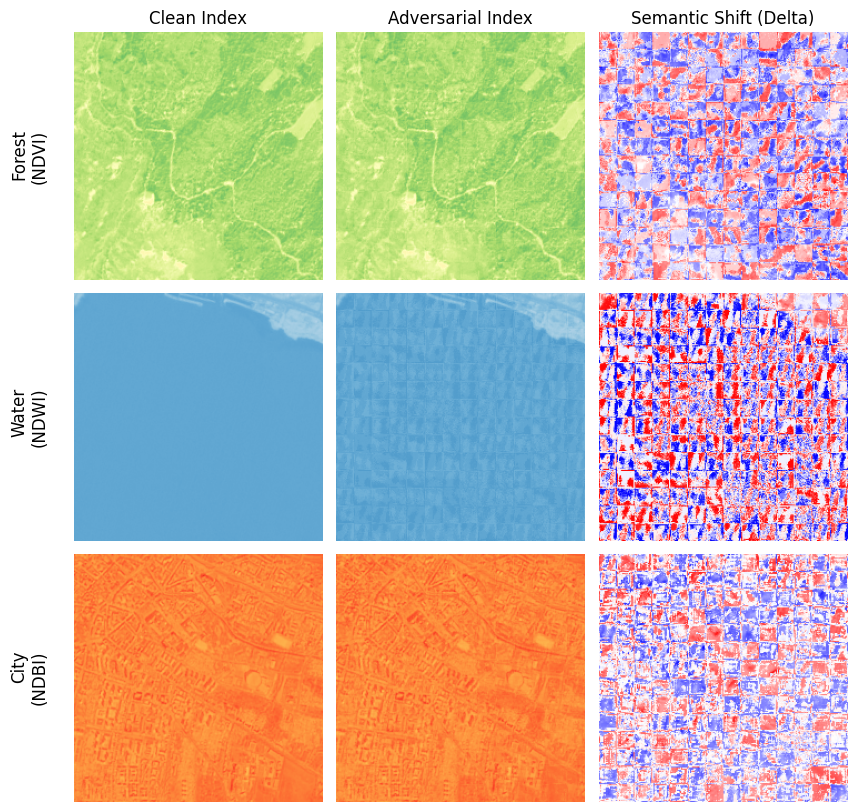

In [4]:
from src.visualization import plot_semantic_shift_grid, plot_all_channels_horizontal
from src.dataset import BANDS_ORDER

print("Visualizing Semantic Shift (Adversarial Physical Indices)...")

# 1. Extract tensors in the exact order expected by the visualization grid: [NDVI, NDWI, NDBI]
ordered_keys = ["NDVI_Target", "NDWI_Target", "NDBI_Target"]

t_orig_list = [viz_data[k]["orig"] for k in ordered_keys]
t_adv_list = [viz_data[k]["adv"] for k in ordered_keys]
labels = [viz_data[k]["label"] for k in ordered_keys]

# Execute the 3x3 Semantic Shift Plot
plot_semantic_shift_grid(t_orig_list, t_adv_list, labels)
